In [ ]:
import cv2
import numpy as np
import json
import os
from copy import deepcopy
import random
from pathlib import Path
import matplotlib.pyplot as plt
from google.colab import drive
from collections import Counter

In [ ]:
# Mount Google Drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Set random seed for reproducibility
random.seed(42)
np.random.seed(42)

In [ ]:
# Paths
base_dir = "/content/drive/MyDrive/Project_Hole_images2"
input_image_dir = base_dir
input_json_path = os.path.join(base_dir, "annotations/merged_annotations.json")
output_image_dir = os.path.join(base_dir, "augmented_images")
output_json_path = os.path.join(base_dir, "augmented_annotations.json")
viz_output_dir = os.path.join(base_dir, "visualizations")

In [ ]:
# Ensure output directories exist
Path(output_image_dir).mkdir(parents=True, exist_ok=True)
Path(viz_output_dir).mkdir(parents=True, exist_ok=True)

In [ ]:
# Load COCO annotations
with open(input_json_path, 'r') as f:
    coco_data = json.load(f)

In [ ]:
# Extract image and annotation data
images = coco_data['images']
annotations = coco_data['annotations']
categories = coco_data['categories']

In [ ]:
# Dynamically identify hole category ID (most common category in annotations)
category_counts = Counter(ann['category_id'] for ann in annotations)
hole_cat_id = category_counts.most_common(1)[0][0] if category_counts else None
if hole_cat_id is None:
    raise ValueError("No annotations found to determine hole category ID. Please check your JSON file.")
print(f"Detected hole category ID: {hole_cat_id}")

Detected hole category ID: 1


In [ ]:
# Identify images with and without holes
image_ids_with_holes = set(ann['image_id'] for ann in annotations)
images_with_holes = [img for img in images if img['id'] in image_ids_with_holes]
images_without_holes = [img for img in images if img['id'] not in image_ids_with_holes]

In [ ]:
# Count annotations per image to identify multiple holes
ann_per_image = {img_id: count for img_id, count in Counter(ann['image_id'] for ann in annotations).items()}

In [ ]:
# Target counts
target_total = 1500
target_with_holes = 750
target_without_holes = 750

In [ ]:
# Calculate base augmentation needed
orig_with_holes = len(images_with_holes)  # ~127
orig_without_holes = len(images_without_holes)  # ~253
base_aug_per_with_holes = (target_with_holes - orig_with_holes) / orig_with_holes  # ~4.9
base_aug_per_without_holes = (target_without_holes - orig_without_holes) / orig_without_holes  # ~1.96

In [ ]:
# Augmentation functions
def adjust_hue(image, hue_shift):
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)
    # Convert to int16 to handle negative shifts, then clamp to 0-179
    h = h.astype(np.int16) + hue_shift
    h = np.clip(h, 0, 179)  # Clamp to HSV hue range
    h = h.astype(np.uint8)  # Convert back to uint8
    hsv = cv2.merge([h, s, v])
    return cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)

def rotate_image_and_bbox(image, bboxes, angle, img_w, img_h):
    center = (img_w / 2, img_h / 2)
    M = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, M, (img_w, img_h))

    new_bboxes = []
    for bbox in bboxes:
        x, y, w, h = bbox
        points = np.array([
            [x, y],
            [x + w, y],
            [x + w, y + h],
            [x, y + h]
        ])
        points = np.hstack([points, np.ones((4, 1))])
        transformed = (M @ points.T).T
        x_min, y_min = transformed[:, 0].min(), transformed[:, 1].min()
        x_max, y_max = transformed[:, 0].max(), transformed[:, 1].max()
        new_bboxes.append([x_min, y_min, x_max - x_min, y_max - y_min])
    return rotated, new_bboxes

In [ ]:
# Augmentation parameters
hue_shifts = [-30, -20, -10, 10, 20, 30]
angles = [-30, -20, 20, 30]

# New COCO data
new_images = []
new_annotations = []
new_image_id = max(img['id'] for img in images) + 1
new_ann_id = max(ann['id'] for ann in annotations) + 1

# Store augmented images for visualization
augmented_with_holes_for_viz = []


In [ ]:
# Function to augment images with priority for multiple holes
def augment_images(image_list, target_count, has_holes, base_aug_per_image):
    orig_count = len(image_list)
    current_count = orig_count
    aug_images = []

    for img in image_list:
        img_path = os.path.join(input_image_dir, img['file_name'])
        image = cv2.imread(img_path)
        if image is None:
            print(f"Failed to load {img_path}, skipping...")
            continue

        aug_images.append((img, image, []))
        current_count += 1

        bboxes = []
        img_anns = []
        if has_holes:
            img_anns = [ann for ann in annotations if ann['image_id'] == img['id']]
            bboxes = [[ann['bbox'][0], ann['bbox'][1], ann['bbox'][2], ann['bbox'][3]] for ann in img_anns]

        # Determine augmentation factor based on multiple holes
        img_id = img['id']
        num_holes = ann_per_image.get(img_id, 0)
        if has_holes and num_holes > 3:
            num_aug = max(20, int(base_aug_per_image * 4))  # Increased for multiple holes
        elif has_holes:
            num_aug = max(10, int(base_aug_per_image * 2))  # Increased for all hole images
        else:
            num_aug = int(base_aug_per_image) + (1 if random.random() < (base_aug_per_image % 1) else 0)  # Keep same for defect-free

        for i in range(num_aug):
            if current_count >= target_count and has_holes:
                # For hole images, continue augmenting until target is reached if possible
                if len([img for img, _, _ in aug_images if img['id'] in image_ids_with_holes]) >= target_with_holes:
                    break
            elif current_count >= target_count:
                break
            hue = random.choice(hue_shifts)
            aug_img = adjust_hue(image, hue)
            angle = random.choice(angles)
            aug_img, new_bboxes = rotate_image_and_bbox(aug_img, bboxes, angle, img['width'], img['height'])
            # Debug: Check image shape and type
            if aug_img is None or aug_img.size == 0:
                print(f"Invalid image data for {img['file_name']} at iteration {i}, skipping...")
                continue
            new_filename = f"aug_{new_image_id}_{img['file_name']}"
            save_path = os.path.join(output_image_dir, new_filename)
            success = cv2.imwrite(save_path, aug_img)
            if not success:
                print(f"Failed to save augmented image to {save_path} (shape: {aug_img.shape}, dtype: {aug_img.dtype}), skipping...")
                continue
            aug_images.append((img, aug_img, new_bboxes))
            if has_holes:
                augmented_with_holes_for_viz.append((aug_img, new_bboxes, img_anns))
            current_count += 1

    return aug_images

# Augment images
aug_images_with_holes = augment_images(images_with_holes, target_with_holes, True, base_aug_per_with_holes)
aug_images_without_holes = augment_images(images_without_holes, target_without_holes, False, base_aug_per_without_holes)

# Save augmented images and update COCO data
for img_data, aug_img, bboxes in aug_images_with_holes + aug_images_without_holes:
    new_filename = f"aug_{new_image_id}_{img_data['file_name']}"
    save_path = os.path.join(output_image_dir, new_filename)
    # Debug: Check image shape and type
    if aug_img is None or aug_img.size == 0:
        print(f"Invalid image data for {img_data['file_name']} in final save, skipping...")
        continue
    success = cv2.imwrite(save_path, aug_img)
    if not success:
        print(f"Failed to save augmented image to {save_path} (shape: {aug_img.shape}, dtype: {aug_img.dtype}), skipping...")
        continue

    new_img_entry = deepcopy(img_data)
    new_img_entry['id'] = new_image_id
    new_img_entry['file_name'] = new_filename
    new_images.append(new_img_entry)

    if bboxes:
        img_anns = [ann for ann in annotations if ann['image_id'] == img_data['id']]
        for bbox, orig_ann in zip(bboxes, img_anns):
            new_ann = deepcopy(orig_ann)
            new_ann['id'] = new_ann_id
            new_ann['image_id'] = new_image_id
            new_ann['bbox'] = [float(bbox[0]), float(bbox[1]), float(bbox[2]), float(bbox[3])]
            new_annotations.append(new_ann)
            new_ann_id += 1

    new_image_id += 1

# Create new COCO JSON
new_coco_data = {
    "images": new_images,
    "annotations": new_annotations,
    "categories": categories
}

# Save new COCO JSON
with open(output_json_path, 'w') as f:
    json.dump(new_coco_data, f, indent=2)

In [ ]:
# Visualize dataset balance
with_holes_count = len([img for img in new_images if any(ann['image_id'] == img['id'] for ann in new_annotations)])
without_holes_count = len(new_images) - with_holes_count

plt.figure(figsize=(8, 6))
plt.bar(['With Holes', 'Without Holes'], [with_holes_count, without_holes_count], color=['red', 'green'])
plt.title('Dataset Balance: Images with and without Holes')
plt.ylabel('Number of Images')
plt.savefig(os.path.join(viz_output_dir, 'dataset_balance.png'))
plt.close()

# Visualize annotations on 3 random augmented images with holes
if augmented_with_holes_for_viz:
    selected = random.sample(augmented_with_holes_for_viz, min(3, len(augmented_with_holes_for_viz)))
    for i, (img, bboxes, orig_anns) in enumerate(selected):
        img_viz = img.copy()
        for bbox, ann in zip(bboxes, orig_anns):
            x, y, w, h = [int(v) for v in bbox]
            cv2.rectangle(img_viz, (x, y), (x + w, y + h), (0, 0, 255), 2)  # Red for all holes
            cv2.putText(img_viz, f"{ann['category_id']}", (x, y - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 255), 2)
        cv2.imwrite(os.path.join(viz_output_dir, f'augmented_holes_viz_{i}.png'), img_viz)

print(f"Augmented dataset created with {len(new_images)} images and {len(new_annotations)} annotations.")
print(f"Saved augmented images to {output_image_dir}")
print(f"Saved new annotations to {output_json_path}")
print(f"Visualizations saved to {viz_output_dir}")

Augmented dataset created with 1455 images and 1195 annotations.
Saved augmented images to /content/drive/MyDrive/Project_Hole_images2/augmented_images
Saved new annotations to /content/drive/MyDrive/Project_Hole_images2/augmented_annotations.json
Visualizations saved to /content/drive/MyDrive/Project_Hole_images2/visualizations


Training


In [ ]:
pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 75.3 MB/s eta 0:00:00


In [ ]:
import torch
import torchvision
import ultralytics
import transformers
import datasets
import pycocotools
import os
import json

# Paths
base_dir = "/content/drive/MyDrive/Project_Hole_images2"
aug_json_path = os.path.join(base_dir, "augmented_annotations.json")
image_dir = os.path.join(base_dir, "augmented_images")

# Verify
print(f"Torch: {torch.__version__}")
print(f"Torchvision: {torchvision.__version__}")
print(f"Ultralytics: {ultralytics.__version__}")
print(f"Transformers: {transformers.__version__}")
print(f"Datasets: {datasets.__version__}")
print(f"GPU Available: {torch.cuda.is_available()}")
print(f"Dataset size: {len([f for f in os.listdir(image_dir) if f.endswith(('.jpg', '.png'))])} images")
with open(aug_json_path, 'r') as f:
    coco_data = json.load(f)
print(f"Annotations: {len(coco_data['annotations'])}")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Torch: 2.8.0+cu126
Torchvision: 0.23.0+cu126
Ultralytics: 8.3.209
Transformers: 4.57.0
Datasets: 4.0.0
GPU Available: True
Dataset size: 1670 images
Annotations: 1195


Total images: 1455
Images with holes: 685
Images without holes: 770
Train: 1164 (with holes: 548, without: 616)
Val: 145 (with holes: 68, without: 77)
Test: 146 (with holes: 69, without: 77)
Saved train JSON: 1164 images
Saved val JSON: 145 images
Saved test JSON: 146 images
loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Converted train to YOLO format in /content/drive/MyDrive/Project_Hole_images2/yolo_dataset/train
loading annotations into memory...
Done (t=0.75s)
creating index...
index created!
Converted val to YOLO format in /content/drive/MyDrive/Project_Hole_images2/yolo_dataset/val
loading annotations into memory...
Done (t=0.58s)
creating index...
index created!
Converted test to YOLO format in /content/drive/MyDrive/Project_Hole_images2/yolo_dataset/test
loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


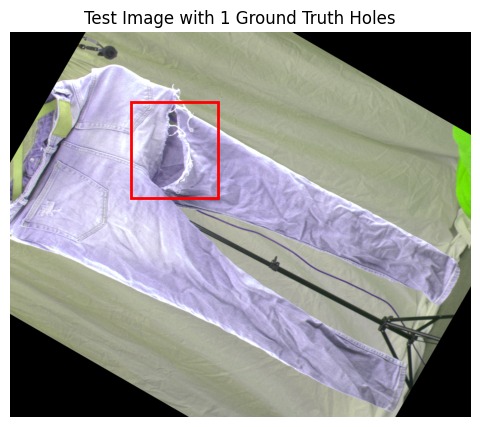

In [ ]:
import os
import json
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from pycocotools.coco import COCO
import shutil
import numpy as np

# Paths
base_dir = "/content/drive/MyDrive/Project_Hole_images2"
aug_json_path = os.path.join(base_dir, "augmented_annotations.json")
image_dir = os.path.join(base_dir, "augmented_images")
yolo_base = os.path.join(base_dir, "yolo_dataset")

# Load COCO JSON
with open(aug_json_path, 'r') as f:
    coco_data = json.load(f)

images = {img['id']: img for img in coco_data['images']}
annotations = coco_data['annotations']
categories = coco_data['categories']

# Identify images with/without annotations
img_ids_with_annos = set(anno['image_id'] for anno in annotations)
img_ids = list(images.keys())
labels = [1 if img_id in img_ids_with_annos else 0 for img_id in img_ids]
print(f"Total images: {len(img_ids)}")
print(f"Images with holes: {sum(labels)}")
print(f"Images without holes: {len(img_ids) - sum(labels)}")

# Stratified split
train_ids, temp_ids, train_labels, temp_labels = train_test_split(
    img_ids, labels, test_size=0.2, stratify=labels, random_state=42
)
val_ids, test_ids, val_labels, test_labels = train_test_split(
    temp_ids, temp_labels, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_ids)} (with holes: {sum(train_labels)}, without: {len(train_ids) - sum(train_labels)})")
print(f"Val: {len(val_ids)} (with holes: {sum(val_labels)}, without: {len(val_ids) - sum(val_labels)})")
print(f"Test: {len(test_ids)} (with holes: {sum(test_labels)}, without: {len(test_ids) - sum(test_labels)})")

# Save split JSONs (include all images)
def get_annos_for_ids(img_ids_list, split_name):
    split_annos = []
    split_images = []
    for img_id in img_ids_list:
        img = images[img_id]
        img_annos = [anno for anno in annotations if anno['image_id'] == img_id]
        split_images.append(img)
        split_annos.extend(img_annos)
    return {'images': split_images, 'annotations': split_annos, 'categories': categories}

for split, ids in [('train', train_ids), ('val', val_ids), ('test', test_ids)]:
    split_data = get_annos_for_ids(ids, split)
    split_path = os.path.join(base_dir, f"{split}_annotations.json")
    with open(split_path, 'w') as f:
        json.dump(split_data, f)
    print(f"Saved {split} JSON: {len(split_data['images'])} images")

# Convert to YOLO format (include empty images)
def convert_coco_to_yolo(coco_json_path, image_dir, output_dir, split):
    os.makedirs(output_dir, exist_ok=True)
    coco = COCO(coco_json_path)
    img_ids = coco.getImgIds()

    for img_id in img_ids:
        img_info = coco.loadImgs(img_id)[0]
        file_name = img_info['file_name']
        img_path = os.path.join(image_dir, file_name)
        if not os.path.exists(img_path):
            print(f"Warning: {img_path} not found")
            continue

        shutil.copy(img_path, os.path.join(output_dir, file_name))

        ann_ids = coco.getAnnIds(imgIds=img_id)
        annos = coco.loadAnns(ann_ids)

        txt_path = os.path.join(output_dir, file_name.rsplit('.', 1)[0] + '.txt')
        with open(txt_path, 'w') as f:
            img_w, img_h = img_info['width'], img_info['height']
            for anno in annos:
                cat_id = anno['category_id'] - 1
                bbox = anno['bbox']
                x_center = (bbox[0] + bbox[2]/2) / img_w
                y_center = (bbox[1] + bbox[3]/2) / img_h
                width = bbox[2] / img_w
                height = bbox[3] / img_h
                f.write(f"{cat_id} {x_center} {y_center} {width} {height}\n")

    print(f"Converted {split} to YOLO format in {output_dir}")

for split in ['train', 'val', 'test']:
    json_path = os.path.join(base_dir, f"{split}_annotations.json")
    out_dir = os.path.join(yolo_base, split)
    convert_coco_to_yolo(json_path, image_dir, out_dir, split)

# Visualize annotations (select image with holes)
coco = COCO(os.path.join(base_dir, 'test_annotations.json'))
img_ids_with_holes = [img_id for img_id in coco.getImgIds() if coco.getAnnIds(imgIds=img_id)]
if img_ids_with_holes:
    img_id = img_ids_with_holes[0]
    img_info = coco.loadImgs(img_id)[0]
    img_path = os.path.join(image_dir, img_info['file_name'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ann_ids = coco.getAnnIds(imgIds=img_id)
    annos = coco.loadAnns(ann_ids)

    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    for anno in annos:
        bbox = anno['bbox']
        x, y, w, h = bbox
        plt.gca().add_patch(plt.Rectangle((x, y), w, h, edgecolor='red', facecolor='none', lw=2))
    plt.title(f"Test Image with {len(annos)} Ground Truth Holes")
    plt.axis('off')
    plt.show()
else:
    print("No test images with holes found for visualization")

In [ ]:
model = YOLO('yolo11n.pt')

In [ ]:
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import json
import torch

def evaluate_model(model, data_loader, device, coco_gt_path):
    model.eval()
    coco_gt = COCO(coco_gt_path)
    results = []
    with torch.no_grad():
        for images, targets in data_loader:
            images = list(img.to(device) for img in images)
            outputs = model(images)
            for target, output in zip(targets, outputs):
                img_id = target['image_id'].item()
                boxes = output['boxes'].cpu().numpy()
                scores = output['scores'].cpu().numpy()
                labels = output['labels'].cpu().numpy()
                for box, score, label in zip(boxes, scores, labels):
                    x, y, w, h = box
                    results.append({
                        'image_id': img_id,
                        'category_id': int(label),
                        'bbox': [float(x), float(y), float(w), float(h)],
                        'score': float(score)
                    })
    # Save predictions
    with open('predictions.json', 'w') as f:
        json.dump(results, f)
    coco_dt = coco_gt.loadRes('predictions.json')
    coco_eval = COCOeval(coco_gt, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()
    print(f"AP_small (1-2mm holes): {coco_eval.stats[3]:.3f}")  # AP for small objects
    return coco_eval.stats[0]  # mAP@0.5:0.95

New https://pypi.org/project/ultralytics/8.3.208 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.207 🚀 Python-3.12.11 torch-2.8.0+cu126 CUDA:0 (NVIDIA A100-SXM4-40GB, 40507MiB)
engine/trainer: agnostic_nms=False, amp=True, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/content/yolo_config.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=200, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.005, lrf=0.001, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo11s.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train3, nbs=64, nms=False, o

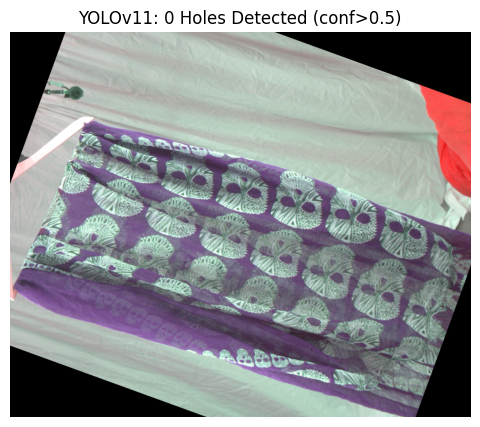

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Error during pycocotools evaluation: 'info'


In [ ]:
import os
import cv2
import matplotlib.pyplot as plt
from ultralytics import YOLO
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import numpy as np

# YOLO config
yolo_yaml = """
path: /content/drive/MyDrive/Project_Hole_images2/yolo_dataset
train: train
val: val
test: test
nc: 1
names: ['hole']
# Augmentation
hsv_h: 0.015
hsv_s: 0.7
hsv_v: 0.4
degrees: 10.0
translate: 0.1
scale: 0.5
shear: 2.0
perspective: 0.0001
flipud: 0.5
fliplr: 0.5
mosaic: 1.0
mixup: 0.2
"""

with open('/content/yolo_config.yaml', 'w') as f:
    f.write(yolo_yaml)

# Load pretrained model - Changed to yolo11s.pt as requested
model = YOLO("yolo11m.pt")  # Triggers download

# Train with explicit YAML path and adjusted parameters
results = model.train(
    data='/content/yolo_config.yaml',
    epochs=200,
    imgsz=640,
    batch=16, # Keep batch size as 16 for now, can be adjusted if memory allows
    lr0=0.005, # Reduced initial learning rate
    lrf=0.001, # Adjusted final learning rate
    momentum=0.937,
    weight_decay=0.0005,
    warmup_epochs=3,
    cos_lr=True,
    optimizer='AdamW',
    device=0,
    patience=30, # Increased patience
    augment=True,
    # Consider slightly adjusting some augmentation parameters if needed, e.g.:
    # scale=0.6,
    # shear=1.5,
)

# Validate
metrics = model.val(data='/content/yolo_config.yaml', split='test')
print(f"YOLOv11 mAP50: {metrics.box.map50}")

# Predict and visualize
test_dir = os.path.join(base_dir, "yolo_dataset/test")
# Select a test image path - need to ensure it's one with annotations for meaningful visualization
# Load the test annotations to find an image with a hole
try:
    coco_test_viz = COCO(os.path.join(base_dir, 'test_annotations.json'))
    img_ids_with_holes_viz = coco_test_viz.getImgIds(catIds=coco_test_viz.getCatIds(catNms=['hole']))
    if img_ids_with_holes_viz:
        img_id_viz = random.choice(img_ids_with_holes_viz)
        img_info_viz = coco_test_viz.loadImgs(img_id_viz)[0]
        test_img_path = os.path.join(test_dir, img_info_viz['file_name'])
    else:
        # If no images with holes in test set, just pick the first one
        test_img_path = os.path.join(test_dir, os.listdir(test_dir)[0])
        # Attempt to get image_id from filename, handle potential ValueError
        try:
            img_id_viz = int(os.path.basename(test_img_path).split('.')[0])
            coco_test_viz = COCO(os.path.join(base_dir, 'test_annotations.json')) # Load COCO for viz GT
            img_info_viz = coco_test_viz.loadImgs(img_id_viz)[0]
        except ValueError:
            print(f"Warning: Could not parse image ID from filename {os.path.basename(test_img_path)}. Skipping visualization.")
            test_img_path = None # Skip visualization if ID cannot be parsed

except Exception as e:
    print(f"Could not find an image with holes for visualization: {e}. Picking first image.")
    test_img_path = os.path.join(test_dir, os.listdir(test_dir)[0])
    # Attempt to get image_id from filename, handle potential ValueError
    try:
        img_id_viz = int(os.path.basename(test_img_path).split('.')[0])
        coco_test_viz = COCO(os.path.join(base_dir, 'test_annotations.json')) # Load COCO for viz GT
        img_info_viz = coco_test_viz.loadImgs(img_id_viz)[0]
    except ValueError:
        print(f"Warning: Could not parse image ID from filename {os.path.basename(test_img_path)}. Skipping visualization.")
        test_img_path = None # Skip visualization if ID cannot be parsed


if test_img_path:
    results = model.predict(test_img_path, conf=0.5)

    img = cv2.imread(test_img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    # Check if results and boxes exist before accessing attributes
    if results and results[0].boxes and results[0].boxes.data.numel() > 0:
        boxes = results[0].boxes.xyxy.cpu().numpy()
        scores = results[0].boxes.conf.cpu().numpy()

        for box, score in zip(boxes, scores):
            if score > 0.5:
                x1, y1, x2, y2 = map(int, box)
                cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 2)

    plt.figure(figsize=(10, 5))
    plt.imshow(img)
    # Update title to reflect actual number of detections if any
    num_detections = len([s for s in scores if s > 0.5]) if 'scores' in locals() else 0
    plt.title(f"YOLOv11: {num_detections} Holes Detected (conf>0.5)")
    plt.axis('off')
    plt.show()

    # mAP with pycocotools on test set
    # Need to get all predictions for all test images to calculate mAP
    test_predictions_coco_format = []
    coco_test_eval = COCO(os.path.join(base_dir, 'test_annotations.json'))
    test_img_ids = coco_test_eval.getImgIds()

    for img_id_eval in test_img_ids:
        img_info_eval = coco_test_eval.loadImgs(img_id_eval)[0]
        img_path_eval = os.path.join(test_dir, img_info_eval['file_name'])
        if os.path.exists(img_path_eval):
             results_eval = model.predict(img_path_eval, verbose=False) # Run prediction
             # Check if results, boxes, and data exist before accessing numel()
             if results_eval and results_eval[0].boxes and results_eval[0].boxes.data.numel() > 0:
                 boxes_eval = results_eval[0].boxes.xyxy.cpu().numpy()
                 scores_eval = results_eval[0].boxes.conf.cpu().numpy()
                 for box_eval, score_eval in zip(boxes_eval, scores_eval):
                      # Assuming category ID 1 for 'hole' based on dataset
                      x1, y1, x2, y2 = box_eval
                      test_predictions_coco_format.append({
                          'image_id': img_id_eval, # Use the correct integer image ID
                          'category_id': 1,
                          'bbox': [float(x1), float(y1), float(x2-x1), float(y2-y1)],
                          'score': float(score_eval)
                      })

    if test_predictions_coco_format:
        try:
            coco_dt_test = coco_test_eval.loadRes(test_predictions_coco_format)
            coco_eval_test = COCOeval(coco_test_eval, coco_dt_test, 'bbox')
            # Assuming category ID 1 is for 'hole' and is the only category for evaluation
            coco_eval_test.params.catIds = [1]
            coco_eval_test.evaluate()
            coco_eval_test.accumulate()
            coco_eval_test.summarize()
            print(f"YOLOv11 pycocotools mAP50: {coco_eval_test.stats[1]}")
        except Exception as e:
            print(f"Error during pycocotools evaluation: {e}")
    else:
        print("No predictions generated on the test set for pycocotools evaluation.")

In [ ]:
import os
import shutil

# Define the source and destination directories
yolo_run_dir = '/content/runs/detect/train3/weights/' # Default Ultralytics save location
destination_dir = os.path.join(base_dir, 'yolo_dataset')

# Ensure the destination directory exists
os.makedirs(destination_dir, exist_ok=True)

# Define the model file names
best_model_file = 'best.pt'
last_model_file = 'last.pt'

# Define the full source paths
best_model_src = os.path.join(yolo_run_dir, best_model_file)
last_model_src = os.path.join(yolo_run_dir, last_model_file)

# Define the full destination paths
best_model_dst = os.path.join(destination_dir, best_model_file)
last_model_dst = os.path.join(destination_dir, last_model_file)

# Copy the model files
if os.path.exists(best_model_src):
    shutil.copy2(best_model_src, best_model_dst)
    print(f"Copied best model to: {best_model_dst}")
else:
    print(f"Best model not found at: {best_model_src}")

if os.path.exists(last_model_src):
    shutil.copy2(last_model_src, last_model_dst)
    print(f"Copied last model to: {last_model_dst}")
else:
    print(f"Last model not found at: {last_model_src}")

Copied best model to: /content/drive/MyDrive/Project_Hole_images2/yolo_dataset/best.pt
Copied last model to: /content/drive/MyDrive/Project_Hole_images2/yolo_dataset/last.pt
